<a href="https://colab.research.google.com/github/ShaheenPafiast/shaheenfirstCode/blob/main/Digital%20Image%20Processing%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Name ......................Abdullah Shaheen**

# **Class .....................AI-Blue(2022-2026)**

# **Reg No. ...................B22AIF1045AI114**

# **Submitted To...............Sir Rizwan Shah**

# Lab report ................8


# **Course Content**
Image Processing Basics

Fourier Transform in Image Processing

Frequency Domain Filtering

Inverse Fourier Transform

Visualization of Results


# ** Load a Grayscale Image**

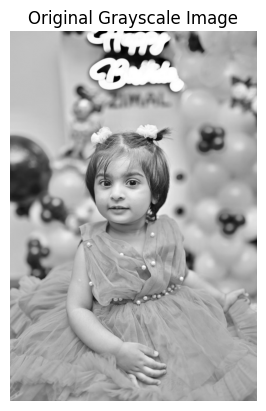

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load a grayscale image
image = cv2.imread("/content/ZIMAL DIAMA.jpg", cv2.IMREAD_GRAYSCALE)

# Display the image
plt.imshow(image, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


# **Compute Fourier Transform & Magnitude Spectr**

This step applies the Fourier Transform, shifts the zero frequency component to the center, and visualizes the Magnitude Spectrum.

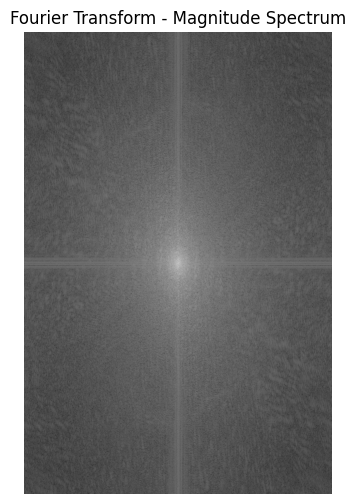

In [3]:
# Apply Discrete Fourier Transform (DFT)
dft = np.fft.fft2(image)

# Shift the zero frequency component to the center
dft_shift = np.fft.fftshift(dft)

# Compute the Magnitude Spectrum
magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)  # Adding 1 to avoid log(0)

# Display the Magnitude Spectrum
plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Fourier Transform - Magnitude Spectrum")
plt.axis("off")
plt.show()


#Apply Low-Pass Filtering (Smoothing)


This step applies a Low-Pass Filter to remove high-frequency components, resulting in a blurred image.



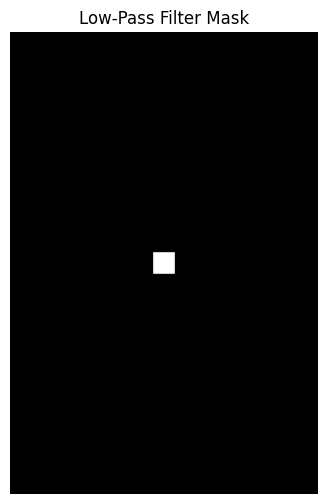

In [5]:
# Create a Low-Pass Filter Mask
rows, cols = image.shape
crow, ccol = rows // 2 , cols // 2  # Center coordinates

mask = np.zeros((rows, cols), np.uint8)
cutoff = 30  # Adjust cutoff frequency
mask[crow - cutoff:crow + cutoff, ccol - cutoff:ccol + cutoff] = 1

# Apply the mask to the Fourier-transformed image
dft_low_pass = dft_shift * mask

# Display the Low-Pass Filter Mask
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap='gray')
plt.title("Low-Pass Filter Mask")
plt.axis("off")
plt.show()


# Reconstruct Image from Low-Pass Filter

This step applies a Low-Pass Filter to remove high-frequency components, resulting in a blurred image.



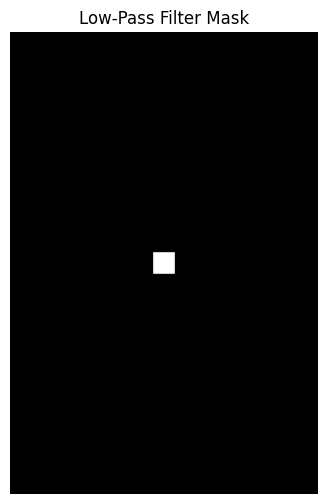

In [6]:
# Create a Low-Pass Filter Mask
rows, cols = image.shape
crow, ccol = rows // 2 , cols // 2  # Center coordinates

mask = np.zeros((rows, cols), np.uint8)
cutoff = 30  # Adjust cutoff frequency
mask[crow - cutoff:crow + cutoff, ccol - cutoff:ccol + cutoff] = 1

# Apply the mask to the Fourier-transformed image
dft_low_pass = dft_shift * mask

# Display the Low-Pass Filter Mask
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap='gray')
plt.title("Low-Pass Filter Mask")
plt.axis("off")
plt.show()


#Reconstruct Image from Low-Pass Filter
This step converts the filtered image back to the spatial domain.


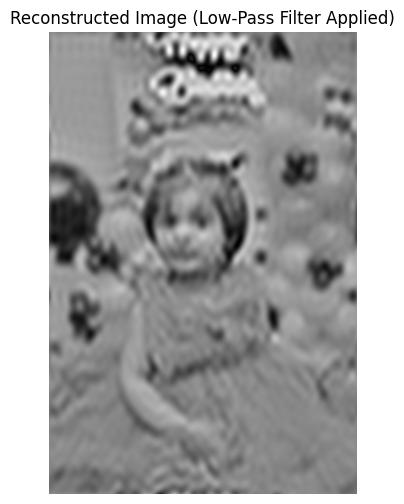

In [7]:
# Shift back the zero frequency component
dft_ishift = np.fft.ifftshift(dft_low_pass)

# Apply Inverse Fourier Transform
image_low_pass = np.fft.ifft2(dft_ishift)
image_low_pass = np.abs(image_low_pass)

# Display the Reconstructed Image
plt.figure(figsize=(6,6))
plt.imshow(image_low_pass, cmap='gray')
plt.title("Reconstructed Image (Low-Pass Filter Applied)")
plt.axis("off")
plt.show()


#Apply High-Pass Filtering (Sharpening)
This step enhances edges by removing low-frequency components.




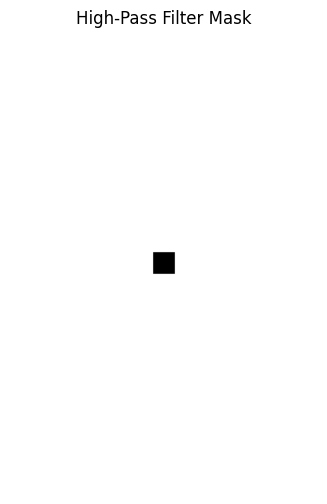

In [8]:
# Create a High-Pass Filter Mask
mask_high = np.ones((rows, cols), np.uint8)
mask_high[crow - cutoff:crow + cutoff, ccol - cutoff:ccol + cutoff] = 0

# Apply the mask to the Fourier-transformed image
dft_high_pass = dft_shift * mask_high

# Display the High-Pass Filter Mask
plt.figure(figsize=(6,6))
plt.imshow(mask_high, cmap='gray')
plt.title("High-Pass Filter Mask")
plt.axis("off")
plt.show()


#Reconstruct Image from High-Pass Filter
This step converts the sharpened image back to the spatial domain.

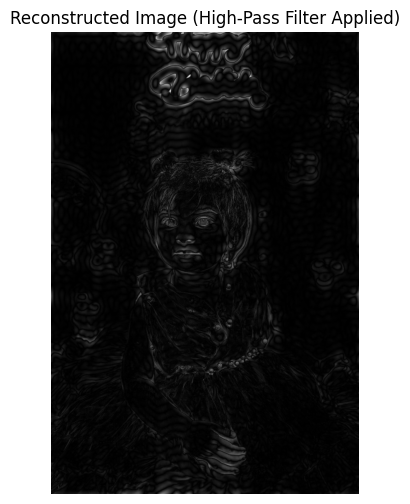

In [9]:
# Shift back the zero frequency component
dft_ishift_high = np.fft.ifftshift(dft_high_pass)

# Apply Inverse Fourier Transform
image_high_pass = np.fft.ifft2(dft_ishift_high)
image_high_pass = np.abs(image_high_pass)

# Display the Reconstructed Image
plt.figure(figsize=(6,6))
plt.imshow(image_high_pass, cmap='gray')
plt.title("Reconstructed Image (High-Pass Filter Applied)")
plt.axis("off")
plt.show()


All the images in one cell

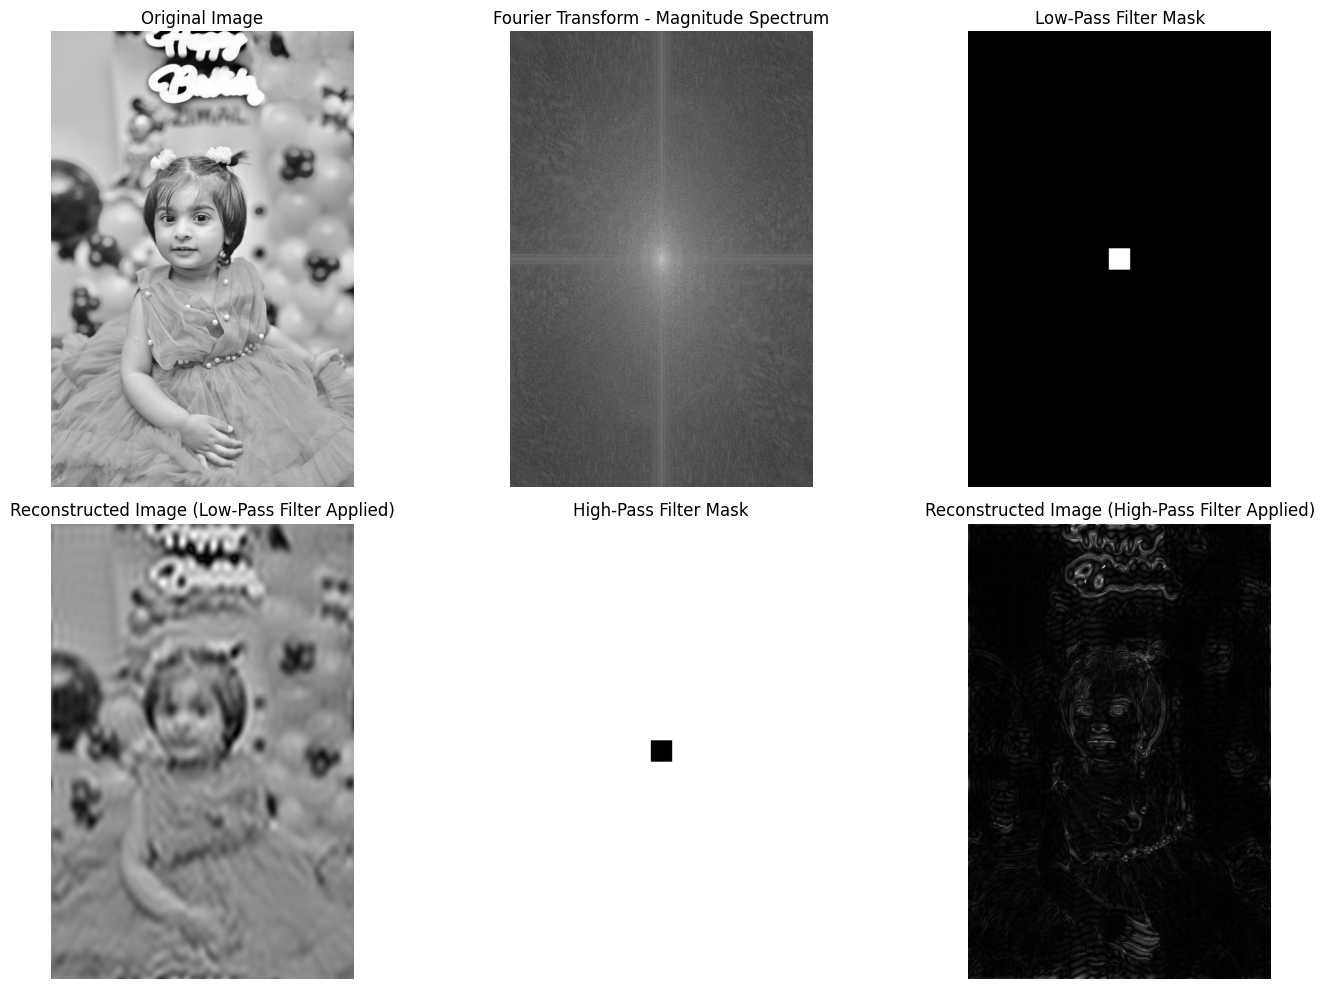

In [10]:
# Create a figure to display all results in one frame
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original Image
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Fourier Magnitude Spectrum
axes[0, 1].imshow(magnitude_spectrum, cmap='gray')
axes[0, 1].set_title("Fourier Transform - Magnitude Spectrum")
axes[0, 1].axis("off")

# Low-Pass Filter Mask
axes[0, 2].imshow(mask, cmap='gray')
axes[0, 2].set_title("Low-Pass Filter Mask")
axes[0, 2].axis("off")

# Reconstructed Image (Low-Pass)
axes[1, 0].imshow(image_low_pass, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (Low-Pass Filter Applied)")
axes[1, 0].axis("off")

# High-Pass Filter Mask
axes[1, 1].imshow(mask_high, cmap='gray')
axes[1, 1].set_title("High-Pass Filter Mask")
axes[1, 1].axis("off")

# Reconstructed Image (High-Pass)
axes[1, 2].imshow(image_high_pass, cmap='gray')
axes[1, 2].set_title("Reconstructed Image (High-Pass Filter Applied)")
axes[1, 2].axis("off")

# Adjust layout and display
plt.tight_layout()
plt.show()


 #Convert Low-Pass Filtered Image Back

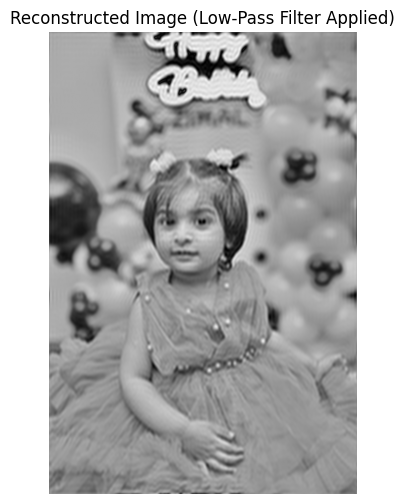

In [20]:
# Shift back the zero frequency component
dft_ishift_low = np.fft.ifftshift(dft_low_pass)

# Apply Inverse Fourier Transform
image_reconstructed_low = np.fft.ifft2(dft_ishift_low)
image_reconstructed_low = np.abs(image_reconstructed_low)
image_reconstructed_low = cv2.normalize(image_reconstructed_low, None, 0, 255, cv2.NORM_MINMAX)
image_reconstructed_low = np.uint8(image_reconstructed_low)

cutoff = 80

# Display the Reconstructed Image (Low-Pass)
plt.figure(figsize=(6,6))
plt.imshow(image_reconstructed_low, cmap='gray')
plt.title("Reconstructed Image (Low-Pass Filter Applied)")
plt.axis("off")
plt.show()


#Apply Low-Pass & High-Pass Filtering with Different Cutoff Values
#We will experiment with three different cutoff values: 20, 50, and 80.
# The results will be displayed side by side for easy comparison.

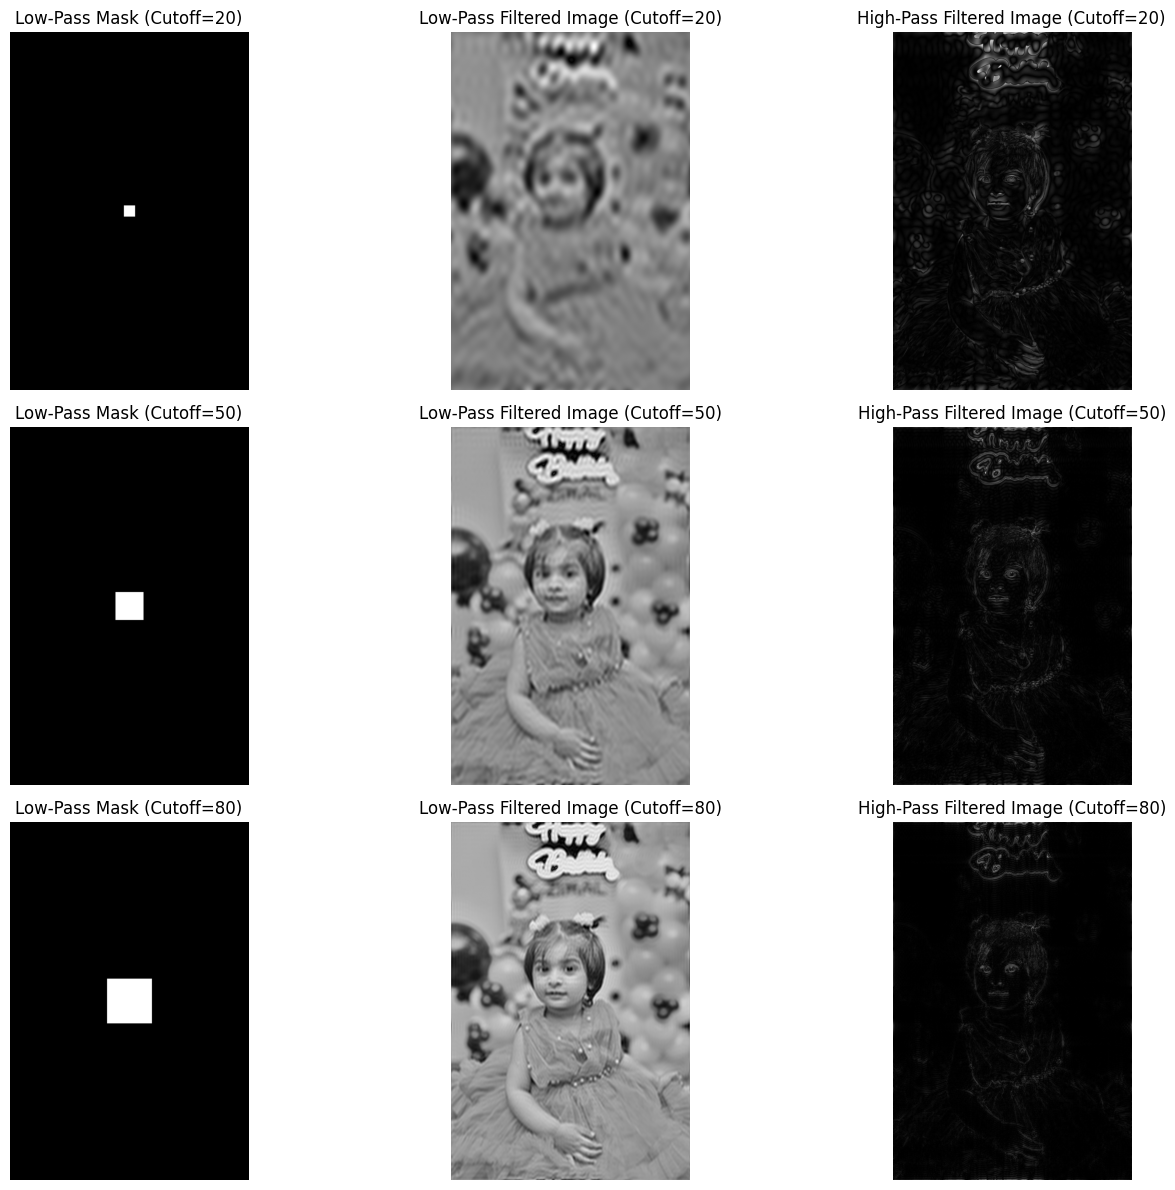

In [19]:
# Define cutoff frequencies for comparison
cutoffs = [20, 50, 80]

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, cutoff in enumerate(cutoffs):
    # Create Low-Pass Filter Mask
    mask_low = np.zeros((rows, cols), np.uint8)
    mask_low[crow - cutoff:crow + cutoff, ccol - cutoff:ccol + cutoff] = 1

    # Apply Low-Pass Filter
    dft_low_pass = dft_shift * mask_low
    dft_ishift_low = np.fft.ifftshift(dft_low_pass)
    image_low_pass = np.fft.ifft2(dft_ishift_low)
    image_low_pass = np.abs(image_low_pass)

    # Create High-Pass Filter Mask
    mask_high = np.ones((rows, cols), np.uint8)
    mask_high[crow - cutoff:crow + cutoff, ccol - cutoff:ccol + cutoff] = 0

    # Apply High-Pass Filter
    dft_high_pass = dft_shift * mask_high
    dft_ishift_high = np.fft.ifftshift(dft_high_pass)
    image_high_pass = np.fft.ifft2(dft_ishift_high)
    image_high_pass = np.abs(image_high_pass)

    # Normalize images for better display
    image_low_pass = (image_low_pass - np.min(image_low_pass)) / (np.max(image_low_pass) - np.min(image_low_pass)) * 255
    image_high_pass = (image_high_pass - np.min(image_high_pass)) / (np.max(image_high_pass) - np.min(image_high_pass)) * 255

    image_low_pass = np.uint8(image_low_pass)
    image_high_pass = np.uint8(image_high_pass)

    # Display Results
    axes[i, 0].imshow(mask_low, cmap='gray')
    axes[i, 0].set_title(f"Low-Pass Mask (Cutoff={cutoff})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(image_low_pass, cmap='gray')
    axes[i, 1].set_title(f"Low-Pass Filtered Image (Cutoff={cutoff})")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(image_high_pass, cmap='gray')
    axes[i, 2].set_title(f"High-Pass Filtered Image (Cutoff={cutoff})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


#**Task: 4**

#Fourier Transform & Magnitude Spectrum
The magnitude spectrum represents the frequency components of an image. The center of the spectrum consists of low-frequency components, whereas the outer areas contain high frequencies. A brighter center indicates a higher presence of low-frequency components, which play a significant role in preserving the overall structure of the image.

#Low-Pass Filtering (Smoothing)
A low-pass filter eliminates high-frequency elements, leading to a blurring effect. A cutoff of 30 results in a strong smoothing effect, making the image appear more blurred. At a cutoff of 60, the filter retains more frequencies, keeping some details visible while still reducing noise. Higher cutoff values cause less blurring because they allow more high frequencies to pass through.



#High-Pass Filtering (Sharpening)
The high-pass filter removes low-frequency components while preserving edges and fine details. With a cutoff of 30, the image has sharper edges but also introduces some noise. A cutoff of 60 retains more low frequencies, slightly reducing the sharpening effect. If the cutoff value is too low, the edges become excessively enhanced, which may lead to unwanted artifacts in the image.



#Inverse Fourier Transform (Reconstruction)
The inverse Fourier transform allows the reconstruction of an image from frequency domain data. When filtering is applied before reconstruction, the resulting image reflects those changes, such as blurring (low-pass filtering) or edge enhancement (high-pass filtering). The accuracy of reconstruction relies on retaining the essential frequency components.

#**Conclusion**

In this lab, we explored Fourier Transform-based image processing techniques to analyze and manipulate images in the frequency domain. We applied low-pass filtering for smoothing and high-pass filtering for sharpening, examining their effects by adjusting different parameter values. Finally, we used the Inverse Fourier Transform to reconstruct images, showcasing how frequency domain modifications influence the spatial representation of images.